In [1]:
import sys
import os
import matplotlib.pyplot as plt
import cv2

import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData
from src.data_processing.dataset_preprocessor import DatasetPreprocessor

In [2]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [ ]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))

# Load the data, all the different stations
data = CoastData(data_path, name="global")

filtered_data = data.get_images_and_masks() 

filtered_data = data.split_data()

CoastData: global - 1717 images
Coast: agrelo, Total size: 244
Coast: arenaldentem, Total size: 40
Coast: cadiz, Total size: 946
Coast: cies, Total size: 430
Coast: samarador, Total size: 57
Image: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/images/1670926246.Tue.Dec.13_11_10_46.CET.2022.arenaldentem.image.jpg
Mask: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/masks/1670926246.Tue.Dec.13_11_10_46.CET.2022.arenaldentem.mask.png


Image: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/images/1575910440.Mon.Dec.09_17_54_00.CET.2019.agrelo.image.jpg
Mask: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/masks/1575910440.Mon.Dec.09_17_54_00.CET.2019.agrelo.mask.png
Image shape: (627, 8320, 3)
Mask shape: (627, 8320)
New image shape: (607, 8141, 3)
New mask shape: (607, 8141)
New mask unique values: (array([0, 1], dtype=uint8), array([2738205, 2203382]))


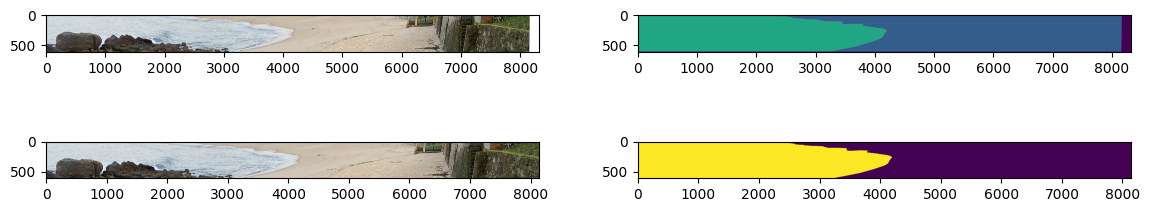

In [ ]:
index = 
# Get the first image and mask
image_path = filtered_data['train']['images'][index]
mask_path = filtered_data['train']['masks'][index]

print("Image:", image_path)
print("Mask:", mask_path)

dataset_preprocessor = DatasetPreprocessor()

image = dataset_preprocessor.load_image(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
mask = dataset_preprocessor.load_mask(mask_path)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

mapping = {
    0: 0,    # Background → Class 0
    25: 1,   # Not classified → Class 1
    75: 2,   # Land → Class 2
    150: 3,  # Sea → Class 3
    255: 4   # Shoreline → Class 4
}

# If we want only 3 classes:
mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 0,   # Land → Class 2
    150: 1,  # Sea → Class 3
    255: 0   # Shoreline → Class 4
}

new_image, new_mask = dataset_preprocessor.process_image_oblique(image, mask, mask_mapping=mapping)
# new_image, new_mask = dataset_preprocessor.process_image(image, mask, mask_mapping=mapping)

print("New image shape:", new_image.shape)
print("New mask shape:", new_mask.shape)

print("New mask unique values:", np.unique(new_mask, return_counts=True))

fig, ax = plt.subplots(2, 2, figsize=(14, 3))


ax[0][0].imshow(image)
ax[0][1].imshow(mask)

ax[1][0].imshow(new_image)
ax[1][1].imshow(new_mask)

plt.show()

In [9]:
mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 0,   # Land → Class 2
    150: 1,  # Sea → Class 3
    255: 0   # Shoreline → Class 4
}

for index in range(len(filtered_data['train']['images'])):
    image_path = filtered_data['train']['images'][index]
    mask_path = filtered_data['train']['masks'][index]

    dataset_preprocessor = DatasetPreprocessor()

    image = dataset_preprocessor.load_image(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    mask = dataset_preprocessor.load_mask(mask_path)

    
    new_image, new_mask = dataset_preprocessor.process_image_oblique(image, mask, mask_mapping=mapping)
    if np.unique(new_mask).tolist() != [0, 1]:
        print(f"Image {index} has unexpected classes in the mask!")
        print("Image path:", image_path)
        print("Mask path:", mask_path)
        print("New mask unique values:", np.unique(new_mask, return_counts=True))

    image_len = image.shape[0]
    new_image_len = new_image.shape[0]

    # if new image is less than 75% of the original, print a warning
    if new_image_len < 0.75 * image_len:
        print(f"Image {index} has been heavily cropped! Original length: {image_len}, New length: {new_image_len}")
        print("Image path:", image_path)
        print("Mask path:", mask_path)
        

Image 182 has been heavily cropped! Original length: 453, New length: 257
Image path: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/images/1670926246.Tue.Dec.13_11_10_46.CET.2022.arenaldentem.image.jpg
Mask path: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/masks/1670926246.Tue.Dec.13_11_10_46.CET.2022.arenaldentem.mask.png


In [ ]:
# Preprocess all the dataset
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_obliques_test_3_classes/"))

dataset_preprocessor = DatasetPreprocessor()

mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 1,   # Land → Class 2
    150: 2,  # Sea → Class 3
    255: 1   # Shoreline → Class 4
}

dataset_preprocessor.preprocess(dataset_path=data_path, dataset_output_path=new_data_path, mask_mapping=mapping, oblique=False)

In [8]:
# 2 classes
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_obliques_test_2_classes/"))

dataset_preprocessor = DatasetPreprocessor()

mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 0,   # Land → Class 2
    150: 1,  # Sea → Class 3
    255: 0   # Shoreline → Class 4
}

dataset_preprocessor.preprocess(dataset_path=data_path, dataset_output_path=new_data_path, mask_mapping=mapping, oblique=True)

### New dataset

In [ ]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_obliques/"))

# Load the data, all the different stations
data = CoastData(data_path)

filtered_data = data.get_images_and_masks() 

filtered_data = data.split_data()

# Get the first image and mask
image_path = filtered_data['train']['images'][0]
mask_path = filtered_data['train']['masks'][0]

print("Image:", image_path)
print("Mask:", mask_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img)
plt.show()

plt.imshow(mask)
plt.show()